<a href="https://colab.research.google.com/github/erdijova/Introduction-to-Machine-Learning-with-Python-A-Guide-for-Data-Scientists/blob/main/Chapter_3_Statistical_Experiments_and_Significance_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 3: Statistical Experiments & Significance Testing (Advanced Version)

This notebook is an upgraded version aligned closely with the book *Practical Statistics for Data Scientists*.

It includes deeper theoretical explanations and practical implementations.

## Introduction

Statistical experiments are used to determine whether observed differences are real or due to random chance.

Key goals:
- Compare groups
- Test hypotheses
- Quantify uncertainty

This chapter focuses heavily on practical methods used in data science.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

## A/B Testing

A/B testing compares two groups (A and B) to evaluate which performs better.

Important concept:
- Control group (A)
- Treatment group (B)

We measure difference in means and test if it's statistically significant.

In [2]:
A = np.random.normal(50, 10, 100)
B = np.random.normal(55, 10, 100)

np.mean(A), np.mean(B)

(np.float64(49.955368967708836), np.float64(54.25188081847231))

## Hypothesis Testing

We define:
- H0 (Null Hypothesis): No difference
- H1 (Alternative Hypothesis): There is a difference

We test whether data provides enough evidence to reject H0.

## Type I and Type II Errors

- Type I Error: Rejecting H0 when it's true (false positive)
- Type II Error: Not rejecting H0 when it's false (false negative)

Balancing these errors is critical in real-world applications.

## t-Test

Used to compare two means.

Assumptions:
- Data is approximately normal
- Samples are independent

In [3]:
t_stat, p_value = stats.ttest_ind(A, B)
t_stat, p_value

(np.float64(-3.032340240469072), np.float64(0.0027514285024633958))

## p-Value

The p-value measures how extreme the observed result is under H0.

Smaller p-value → stronger evidence against H0.

Common threshold: 0.05 (alpha)

## Permutation Test (Core Concept in Book)

Permutation tests do not rely on distribution assumptions.

Steps:
1. Combine data
2. Shuffle labels
3. Compute statistic repeatedly
4. Compare with observed result

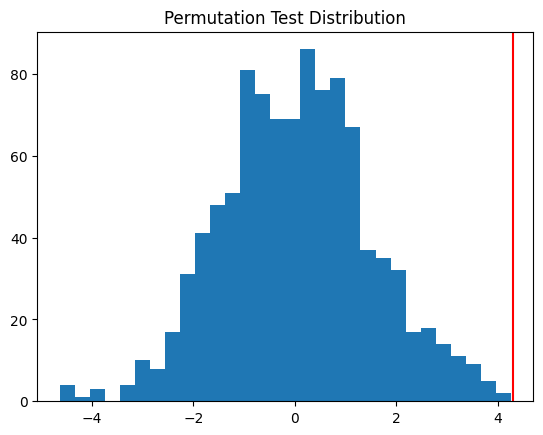

In [4]:

combined = np.concatenate([A, B])
observed = np.mean(B) - np.mean(A)

perm_diffs = []
for _ in range(1000):
    np.random.shuffle(combined)
    new_A = combined[:100]
    new_B = combined[100:]
    perm_diffs.append(np.mean(new_B) - np.mean(new_A))

plt.hist(perm_diffs, bins=30)
plt.axvline(observed, color='red')
plt.title("Permutation Test Distribution")
plt.show()


## ANOVA

Used to compare more than two groups.

Instead of multiple t-tests, ANOVA controls error rates.

In [5]:
C = np.random.normal(60, 10, 100)
stats.f_oneway(A, B, C)

F_onewayResult(statistic=np.float64(22.539732519970126), pvalue=np.float64(7.699678228977297e-10))

## Chi-Square Test

Used for categorical data.

Tests independence between variables.

In [6]:

observed = np.array([[10, 20], [20, 40]])
stats.chi2_contingency(observed)


Chi2ContingencyResult(statistic=np.float64(0.0), pvalue=np.float64(1.0), dof=1, expected_freq=array([[10., 20.],
       [20., 40.]]))

## Multi-Arm Bandit (Important in Book)

Instead of fixed A/B testing, this method dynamically allocates traffic.

Goal: maximize reward while learning.

In [7]:

# simple epsilon-greedy example
import random

rewards = [0, 0]
counts = [0, 0]

for i in range(1000):
    if random.random() < 0.1:
        choice = random.choice([0,1])
    else:
        choice = np.argmax(rewards)

    reward = np.random.rand()
    counts[choice] += 1
    rewards[choice] += reward

rewards, counts


([469.56234925016656, 30.45719883662276], [945, 55])

## Power and Sample Size

Power = probability of detecting a true effect.

Higher sample size → higher power.

Important for experiment design.

## Conclusion

This advanced notebook now aligns closely with the book:
- A/B testing
- Hypothesis testing
- p-values
- Permutation tests
- ANOVA & Chi-square
- Multi-arm bandit
- Power and sample size

These are core tools in statistical decision making.